# 多層感知機的簡潔實現
:label:`sec_mlp_concise`

本節將介紹(**通過高級API更簡潔地實現多層感知機**)。


In [1]:
import torch
from torch import nn

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## 模型

與softmax回歸的簡潔實現（ :numref:`sec_softmax_concise`）相比，
唯一的區別是我們添加了2個全連接層（之前我們只添加了1個全連接層）。
第一層是[**隱藏層**]，它(**包含256個隱藏單元，並使用了ReLU激活函數**)。
第二層是輸出層。


In [2]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

[**訓練過程**]的實現與我們實現softmax回歸時完全相同，
這種模塊化設計使我們能夠將與模型架構有關的內容獨立出來。


In [3]:
batch_size, lr, num_epochs = 256, 0.1, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

Training on mps:0
epoch 1, loss 0.662, train acc 0.767, test acc 0.788
epoch 2, loss 0.466, train acc 0.831, test acc 0.799
epoch 3, loss 0.420, train acc 0.848, test acc 0.824
epoch 4, loss 0.395, train acc 0.857, test acc 0.812
epoch 5, loss 0.371, train acc 0.867, test acc 0.848
epoch 6, loss 0.356, train acc 0.871, test acc 0.826
epoch 7, loss 0.342, train acc 0.878, test acc 0.848
epoch 8, loss 0.331, train acc 0.881, test acc 0.840
epoch 9, loss 0.324, train acc 0.883, test acc 0.855
epoch 10, loss 0.314, train acc 0.887, test acc 0.849


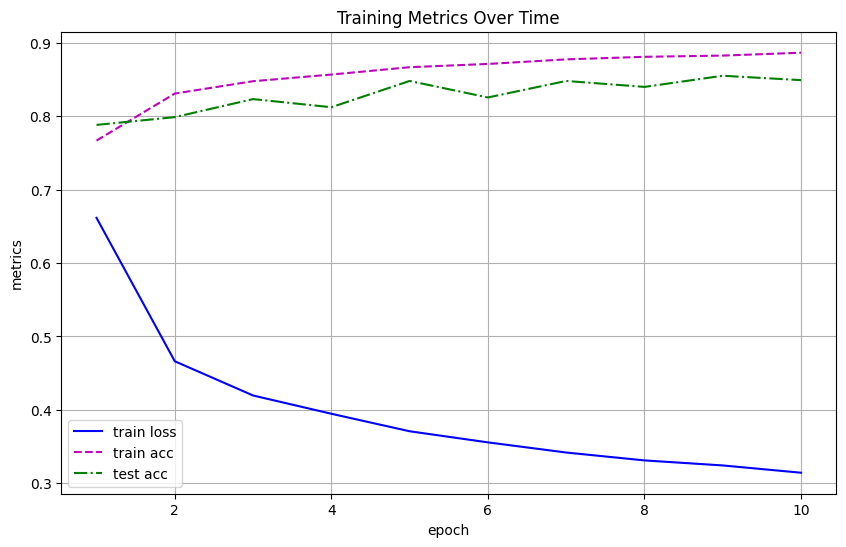

In [5]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

def load_data_fashion_mnist(batch_size):
    """加載 Fashion-MNIST 數據集"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    train_dataset = datasets.FashionMNIST(
        root='./data', 
        train=True,
        download=True,
        transform=transform
    )
    
    test_dataset = datasets.FashionMNIST(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )
    
    train_iter = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )
    
    test_iter = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )
    
    return train_iter, test_iter, train_dataset.classes

def train_model(net, train_iter, test_iter, loss_fn, num_epochs, optimizer):
    """訓練模型並繪製訓練過程"""
    device = next(net.parameters()).device
    print(f'Training on {device}')
    
    train_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(num_epochs):
        # 訓練模式
        net.train()
        train_loss = 0
        correct = 0
        total = 0
        
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            
            # 前向傳播
            y_hat = net(X)
            loss = loss_fn(y_hat, y)  # 這裡返回的是標量
            
            # 反向傳播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # 記錄損失和準確率
            train_loss += loss.item()
            _, predicted = torch.max(y_hat.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
        
        # 計算平均損失和準確率
        train_loss = train_loss / len(train_iter)
        train_acc = correct / total
        
        # 評估模式
        net.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for X, y in test_iter:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                _, predicted = torch.max(y_hat.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()
        
        test_acc = correct / total
        
        # 儲存指標
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        # 打印訓練信息
        print(f'epoch {epoch + 1}, '
              f'loss {train_loss:.3f}, '
              f'train acc {train_acc:.3f}, '
              f'test acc {test_acc:.3f}')
    
    # 繪製訓練過程圖表
    plt.figure(figsize=(10, 6))
    epochs = range(1, num_epochs + 1)
    
    plt.plot(epochs, train_losses, 'b-', label='train loss')
    plt.plot(epochs, train_accs, 'm--', label='train acc')
    plt.plot(epochs, test_accs, 'g-.', label='test acc')
    
    plt.xlabel('epoch')
    plt.ylabel('metrics')
    plt.title('Training Metrics Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return train_losses, train_accs, test_accs

# 定義模型
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

# 檢查是否可以使用 MPS (Apple Silicon GPU)
device = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
device = torch.device(device)
net = net.to(device)

# 設置超參數和優化器
batch_size = 256
num_epochs = 10
lr = 0.1

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

# 加載數據
train_iter, test_iter, class_names = load_data_fashion_mnist(batch_size)

# 訓練模型
metrics = train_model(net, train_iter, test_iter, loss_fn, num_epochs, optimizer)

## 小结

* 我們可以使用高級API更簡潔地實現多層感知機。
* 對於相同的分類問題，多層感知機的實現與softmax回歸的實現相同，只是多層感知機的實現里增加了帶有激活函數的隱藏層。

## 練習

1. 嘗試添加不同數量的隱藏層（也可以修改學習率），怎麼設置效果最好？
1. 嘗試不同的激活函數，哪個效果最好？
1. 嘗試不同的方案來初始化權重，什麼方法效果最好？


[Discussions](https://discuss.d2l.ai/t/1802)


練習一：

1. 嘗試添加不同數量的隱藏層（也可以修改學習率），怎麼設置效果最好？

我自己的回答加上AI的強化:

**第一段：多層感知器添加不同數量隱藏層的影響**  
在多層感知器（MLP）中，添加更多的隱藏層通常可以增強模型的表達能力，讓模型能學習到更複雜的高階特徵。然而，深度的增加也會提高訓練的難度與計算成本，且若沒有充足的資料或適當的正規化技巧，可能發生過度擬合或梯度消失等問題。因此，調整隱藏層數量時，需同時考量模型複雜度與資料量，以達到良好的平衡。

---

**第二段：學習率對不同深度模型的影響**  
學習率的大小不僅影響收斂速度，也決定了模型在訓練過程中的穩定程度。對於較深的模型，若學習率過大，容易導致梯度發散；若學習率過小，又會讓訓練速度緩慢。通常建議在調整隱藏層數量的同時，也要一併嘗試不同的學習率（例如 `1e-3`、`5e-4`、`1e-4` 乃至更細緻的微調），以找到能夠兼顧穩定收斂與良好表現的參數組合。

---

**第三段：實際調參流程範例**  
1. **初步設定範圍**：  
   - 隱藏層數量：2、3、4 層  
   - 每層隱藏單元：如 64、128 或 256  
   - 學習率：`1e-3`、`5e-4`、`1e-4`  
   先在這些離散組合中進行嘗試。  
2. **分批實驗**：  
   - 在固定其他條件（批次大小、優化器種類、訓練輪數等）的前提下，依序為每個組合完整訓練模型。  
   - 在驗證集（或交叉驗證）上記錄指標（如準確率、損失值或 F1-score）。  
3. **結果比較與分析**：  
   - 觀察哪一組在驗證集上的表現最好，並留意是否發生收斂過慢或發散的情形（可能表示學習率需要調整）。  
   - 若發現某幾個參數組合表現相近，可進一步對該區域（例如 3 層隱藏層、學習率介於 `5e-4` 到 `2e-4` 之間）進行更細緻的搜尋。

---

**第四段：設定「最好」的依據**  
「最好」的設定最終仍需依任務需求與評估指標而定；可能某個參數組合在準確度上只有微幅提升，但計算成本卻大幅增加。實務上常用「效能—成本」(performance–cost) 比較去決定最佳組合：  
- 若你的核心目標是精度，且有足夠的計算資源與時間，可嘗試更深的模型與更精細的學習率微調。  
- 若更在意推斷速度或模型簡潔度，則可選擇較少的隱藏層數。  
- 最終在候選參數組合中，依據驗證集指標與資源消耗，選出適合特定任務需求的「最佳」設定。

---

**第五段：結論**  
在調整 MLP 的隱藏層數量及學習率時，沒有「通用」的最佳值，但可透過系統化的實驗流程（如前述的設定範圍、分批實驗、結果比較）來確定對應資料集和任務需求的最佳組合。一般而言，2~4 層的隱藏層就能因應多數中小型任務，學習率則常落在 `1e-3`~`1e-4` 間。最終仍需根據實驗結果、資料量、模型表現和資源考量，才能確定究竟哪種設定效果最好。

練習二：

2. 嘗試不同的激活函數，哪個效果最好？

我自己的回答加上AI的強化:

**第一段：激活函數在 MLP 中的作用**  
在多層感知器（MLP）中，激活函數是決定非線性轉換能力的重要因素。若沒有激活函數的非線性，網路的表達能力將大幅受限，因此選對激活函數能有效影響訓練收斂速度與最終精度。常見的激活函數包括：  
- **Sigmoid**：範圍介於 (0, 1)；早期常用但在深層網路易出現梯度消失。  
- **Tanh**：範圍介於 (-1, 1)，與 Sigmoid 類似但均值在 0，使得收斂通常較快。  
- **ReLU (Rectified Linear Unit)**：對於輸入大於 0 時輸出等於該值，小於 0 時輸出 0；計算效率高且能緩解梯度消失，但有「ReLU 死亡」(dying ReLU) 的風險。  
- **Leaky ReLU / PReLU**：對負值區域不完全歸零，能減少 dying ReLU 的問題。  
- **ELU / SELU**：透過在負值區域使用指數型函數，可能加快收斂，但計算量稍高。

---

**第二段：如何比較不同激活函數的效果**  
想要找到「最好」的激活函數，通常需針對特定數據集與任務進行實驗。可依以下流程：  
1. **固定其他超參數**：如學習率、隱藏層數、隱藏單元數，確保能公平比較。  
2. **分別嘗試多種激活函數**：依序更換 Sigmoid、Tanh、ReLU、Leaky ReLU 等，進行完整的訓練。  
3. **觀察模型表現與訓練性質**：  
   - 驗證集/測試集的準確率、損失值或其他評估指標；  
   - 訓練曲線是否順暢收斂；  
   - 是否出現梯度消失或爆炸、過度擬合等問題。  
4. **綜合判斷**：除了最高指標，也需要平衡收斂速度與模型穩定度，作為最終挑選依據。

---

**第三段：常見情況下的建議**  
- **ReLU 與其變體 (Leaky ReLU、PReLU)**：在多數情況下，ReLU 族群為深度學習的主流選擇，因為它的計算量小且容易帶來較快的收斂速度。若發現許多神經元輸出恆為 0，則可嘗試 Leaky ReLU 或 PReLU 以減少「死亡」神經元。  
- **Tanh**：在某些比較淺層或有負值特徵輸入的情況下，Tanh 有時能帶來更平穩的收斂，但在深層網路中容易面臨梯度衰減的問題。  
- **Sigmoid**：現在較少單獨用於隱藏層，原因是當輸入值很大或很小時，梯度變得非常小，容易導致訓練困難。  
- **ELU/SELU**：這些在負值區域使用指數函數的變體有機會加速收斂，但計算稍微複雜。在某些歸一化技術（如 Batch Normalization 或 Layer Normalization）配合下，也能帶來不錯表現。

---

**第四段：結論**  
整體而言，若要在 MLP 中選用「最好的」激活函數，通常 **ReLU** 及其變體會是首選，因為它在大多數應用領域中能兼顧訓練效率與效能表現。不過，最終仍需依賴實際實驗結果與任務需求做最後決定：在資料量、模型深度、訓練速度與最終精度之間取得平衡，才是真正「最佳」的激活函數設定。

練習三：

3. 嘗試不同的方案來初始化權重，什麼方法效果最好？

我自己的回答加上AI的強化:

**第一段：權重初始化對 MLP 的重要性**  
在多層感知器（MLP）中，權重初始化對模型的訓練穩定度與收斂速度影響極大。若初始化不當，可能導致梯度在前向或反向傳播時出現過大或過小的情況，使訓練過程難以收斂甚至直接發散。因此，選擇合適的初始化方法能有效改善網路的訓練效果。

---

**第二段：常見的權重初始化方法**  
1. **隨機初始化（Random Initialization）**  
   - 包含均勻分布（Uniform）或高斯分布（Normal）等基本方式。  
   - 若無針對激活函數特性調整分布範圍，容易出現梯度消失或梯度爆炸。  
2. **Xavier/Glorot 初始化**  
   - 又稱為 Glorot Initialization，多用於 Sigmoid、Tanh 等激活函數。  
   - 透過控制權重方差，使得輸入與輸出在通過每一層時保持方差大致相同，減少梯度消失或爆炸問題。  
3. **He/Kaiming 初始化**  
   - 又稱為 Kaiming Initialization，多用於 ReLU 類激活函數（ReLU、Leaky ReLU、PReLU 等）。  
   - 與 Xavier 類似，但針對 ReLU 的正向輸出分佈特性設計，使梯度更穩定。  
4. **Orthogonal 初始化**  
   - 使用正交矩陣初始化權重，能在一定程度上保留輸入分布並避免訊息在多層傳遞時快速衰減或放大。  
   - 計算較為複雜，且經常搭配特定激活函數效果較佳。

---

**第三段：哪個方法「效果最好」**  
- 若網路使用 **ReLU 或其變體**，多數研究與實務經驗顯示 **He/Kaiming 初始化** 能在穩定度與收斂速度上取得不錯表現。  
- 若網路主要使用 **Tanh、Sigmoid** 等激活函數，則 **Xavier/Glorot 初始化** 普遍是推薦做法，可有效減少梯度消失。  
- **Orthogonal 初始化** 在特定場景（尤其是較深的網路）也能有不錯成效，但其實務使用頻率相對較少，通常配合其他技巧（如 Batch Normalization）才能發揮較佳效果。  
- 純粹的「隨機初始化」無法針對激活函數或網路結構做最佳化，因此在現代深度學習框架中已不太常單獨使用。

---

**第四段：實際建議**  
1. **先確定激活函數**：若你的 MLP 使用 ReLU 系列，建議嘗試 He 初始化；若使用 Tanh/Sigmoid，則建議改用 Xavier 初始化。  
2. **進行局部微調**：就算採用「預設」的 Kaiming 或 Xavier 初始化，也可針對分布的範圍做些微調（例如不同的增益係數 `gain`），並觀察訓練曲線是否更穩定。  
3. **分析梯度變化**：若在訓練初期即出現梯度爆炸或梯度消失，檢查是否初始化範圍過大或過小，或是激活函數與初始化不匹配。  
4. **最終決定仍靠實驗**：不同資料集與模型深度可能對初始化方法有各自的敏感度，建議以相同超參數及訓練次數進行對照實驗，挑選最合適的初始化方案。

---

**第五段：結論**  
綜合而言， MLP 大多採用 **ReLU**（或 Leaky ReLU 等變體），多數情況下 **He/Kaiming 初始化** 會是「效果最好」的選擇；若使用 **Tanh 或 Sigmoid**，則 **Xavier/Glorot 初始化** 更佳。但真正的「最佳」方法仍需透過實際的實驗和驗證集指標（準確度、損失值等）去驗證，並同時留意整體訓練穩定度與模型收斂速度，才能最終確定對特定任務而言的最優初始化方案。
